# **Exploratory Data Analysis (EDA)**

La estadística descriptiva es una de las herramientas más poderosas dentro de la modelación, pues permite identificar tendencias, detectar valores atípicos, reconocer relaciones entre variables y descubrir posibles errores en los datos.

Antes de la implementación de modelos, como la regresión lineal múltiple o algoritmos de machine learning, un buen análisis preliminar es crucial para garantizar que los supuestos de los modelos se cumplan y obtener resultados confiables. (i.e  normalidad, homocedasticidad, independencia, no correlación).

Antes de **aplicar cualquier técnica de modelación**, es indispensable **realizar un análisis exploratorio de nuestros datos** (EDA).

Es común que se minimice la importancia de esta etapa y se pase directamente a la aplicación de modelos. Entre los errores frecuentes se encuentran: trabajar con datos sin limpiar, interpretar gráficos de manera superficial, ignorar la distribución de las variables, o asumir que todos los registros son igualmente confiables.

El EDA permite **describir/explicar/entender el comportamiento** del fenómeno de interés.



# Componentes del EDA

Aunque no se puede generalizar, estos son algunos puntos indispensables a considerar, en un orden sugerido, cuando se realiza un primer acercamiento a los datos:

1. **Limpieza de la base (qué hacer con valores faltantes — NA)**

El primer paso consiste en revisar la integridad de la base de datos y decidir cómo manejar los valores faltantes. No siempre es adecuado eliminarlos: en ocasiones, los NA pueden tener un significado particular o estar asociados a un **patrón relevante**, otras ocasiones la mayoria de datos faltantes pertecen a **variables especificas que no son relevantes para el objetivo del modelo** (descriptivo, inferencia, predicción). 

Ejemplo: En una base de datos sobre calidad del agua superficial en México, se desea implementar un modelo para predecir la calidad del agua de un cuerpo.

- Variables geográficas no relevantes con NA 
- Observaciones con semáforo verde tienen NA en variable Contaminantes.

-----

2. **Verificar la calidad de la información**

Antes de proceder al análisis, es fundamental comprobar que las mediciones sean coherentes y estén dentro de rangos plausibles. Esto incluye revisar inconsistencias, errores de captura o formatos incorrectos.

Ejemplo: Edades negativas o valores numéricos en campos donde se esperaban cadenas de texto.

-----

3. **Preprocesamiento (tipo de variable y formato)**

En esta etapa se debe verificar que cada variable esté correctamente clasificada según su tipo (numérica continua, entera, categórica, ordinal, etc.) y que su formato sea compatible con las operaciones que se realizarán.

Una variable mal tipificada puede alterar por completo las estadísticas o visualizaciones posteriores.

Ejemplo: Variables categóricas almacenadas como números. (Fumador 0 = No, 1 = Sí)

-----

4. **Análisis univariado y multivariado**

Una vez depurada la base, se procede al análisis estadístico y visual. Aquí se distinguen dos enfoques principales:

- **a) Estadísticas descriptivas**

Es muy importante identificar la escala de las variables (nominal, ordinal, de intervalo o de razón), ya que esto afecta la interpretación de la dispersión aparente y la elección de las medidas de resumen adecuadas.

Las estadísticas descriptivas permiten obtener una primera idea de la forma (asimetria y curtosis), tendencia central (localización) y variabilidad (dispersión) de los datos.

- **b) Visualización de los datos** 

**b.1) Distribución**

El análisis de distribuciones univariadas permite explorar cómo se comporta cada variable individualmente.

En muchos casos, conviene segmentar los datos por categorías para realizar comparaciones, o porque naturalmente se comportan de manera distinta entre categorías (población heterogénea).

En esta fase se pueden **identificar valores atípicos** (outliers) y decidir si conviene mantenerlos o excluirlos del análisis. En general, los outliers deben ser investigados para entender su origen antes de tomar una decisión, en ocasiones pueden aportar información valiosa sobre el fenómeno estudiado.


***Situación para los ejemplos*:**

*Se realiza una investigación sobre la efectividad de diferentes estufas ecológicas frente a fogones tradicionales en una comunidad rural. Se busca simular las actividades diarias de una familia y medir la calidad del aire dentro de la cocina en usando ambos métodos con el objetivo de evaluar el rendimiento de las estufas ecológicas.*


*Para esto, tres voluntarias cocinaron en una casa equipada con ambos métodos de cocción diferentes alimentos cotidianos (arroz, frijoles, etc.), cada voluntaria utilizó el fogón y 3 estufas diferentes (A, B y C) en días separados, mientras se registraban las concentraciones de contaminantes en el aire dentro de la sala.*


En esta fase se pueden **identificar valores atípicos (outliers)** y decidir si conviene **mantenerlos o excluirlos del análisis.**


Ejemplo: Fogón vs. Estufas. ¿Cuándo conviene quitarlos?

También es posible detectar irregularidades en los datos, como la presencia de variables latentes que influyen en las mediciones.

Ejemplo: Mismas estufas con diferentes mediciones según la usuaria.

Por último, pueden revelarse patrones o comportamientos particulares dentro de los datos.

Ejemplo: Las mediciones de una usuaria en específico siempre eran las pequeñas.

\
**b.2) Relaciones y patrones**

**Análisis de correlaciones**:

Permite interpretar las relaciones entre pares de variables y detectar posibles inconsistencias o redundancias.

Se pueden utilizar correlogramas o gráficas bivariadas, siempre que la dimensión de los datos lo permita.

Además, el Análisis de Componentes Principales (PCA) puede emplearse para resumir la información y explorar patrones multivariados.

**Pairplots**:

Consisten en representar todas las combinaciones de variables de dos en dos, lo que ayuda a visualizar de forma simultánea relaciones, concentraciones y posibles grupos dentro de los datos.

# Herramientas computacionales

Algunas herramientas computacionales de utilidad para realizar un EDA decente:

In [1]:
set.seed(123)
library(ggplot2, help, pos = 2, lib.loc = NULL)
library(dplyr, help, pos = 2, lib.loc = NULL)


Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## Manejo de valores faltantes

### Visualización 

La librería `naniar` en R proporciona funciones específicas para visualizar y manejar valores faltantes en conjuntos de datos. Permite identificar patrones de NA y decidir estrategias para su tratamiento.

In [2]:
library(naniar)

#datos de prueba
data(airquality)

# breve vistazo
str(airquality) #falta preprocesamiento
head(airquality)



'data.frame':	153 obs. of  6 variables:
 $ Ozone  : int  41 36 12 18 NA 28 23 19 8 NA ...
 $ Solar.R: int  190 118 149 313 NA NA 299 99 19 194 ...
 $ Wind   : num  7.4 8 12.6 11.5 14.3 14.9 8.6 13.8 20.1 8.6 ...
 $ Temp   : int  67 72 74 62 56 66 65 59 61 69 ...
 $ Month  : int  5 5 5 5 5 5 5 5 5 5 ...
 $ Day    : int  1 2 3 4 5 6 7 8 9 10 ...


,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


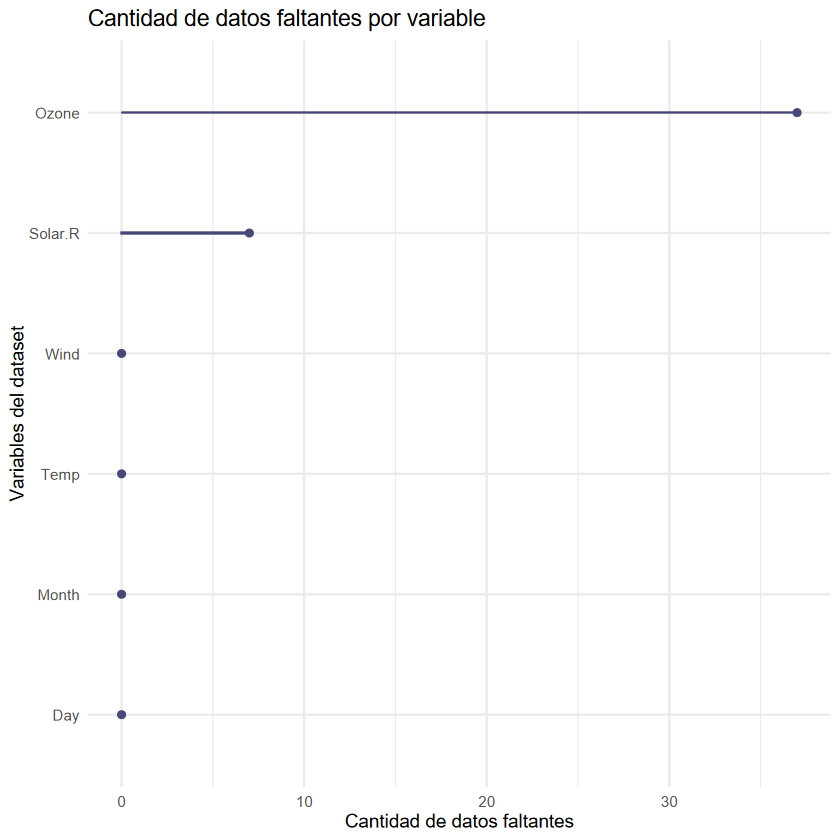

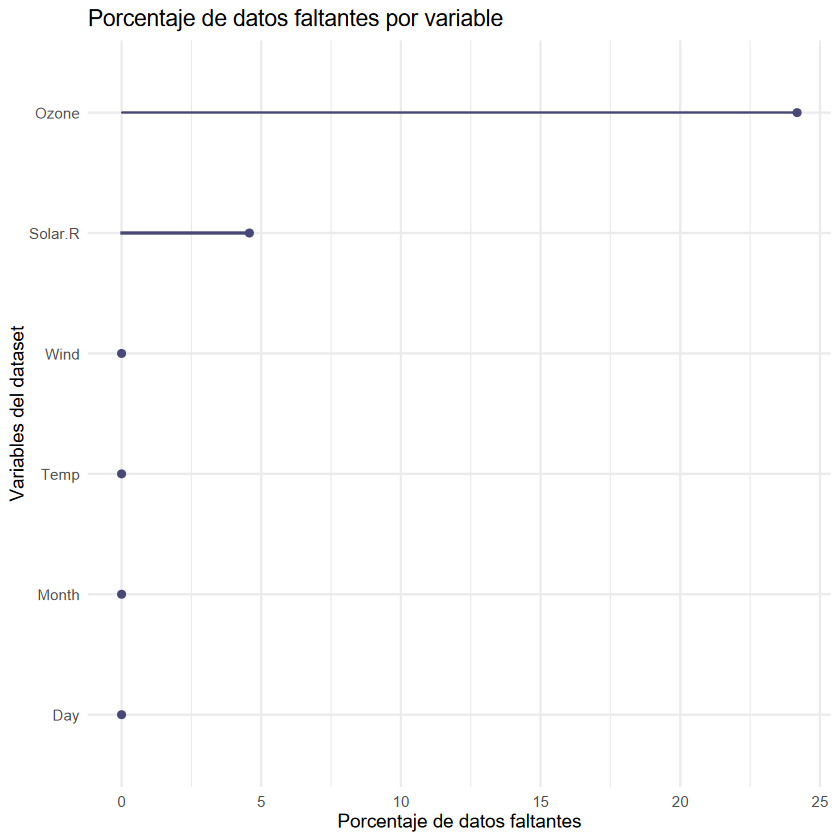

In [ ]:

# cantidad de datos faltantes por variable
gg_miss_var(airquality, show_pct = FALSE) +
  labs(y = "Cantidad de datos faltantes", x = "Variables del dataset",
       title = "Cantidad de datos faltantes por variable") +
  theme_minimal()


# proporcion de datos faltantes por variable
gg_miss_var(airquality, show_pct = TRUE) +
  labs(y = "Porcentaje de datos faltantes", x = "Variables del dataset",
       title = "Porcentaje de datos faltantes por variable") +
  theme_minimal()  


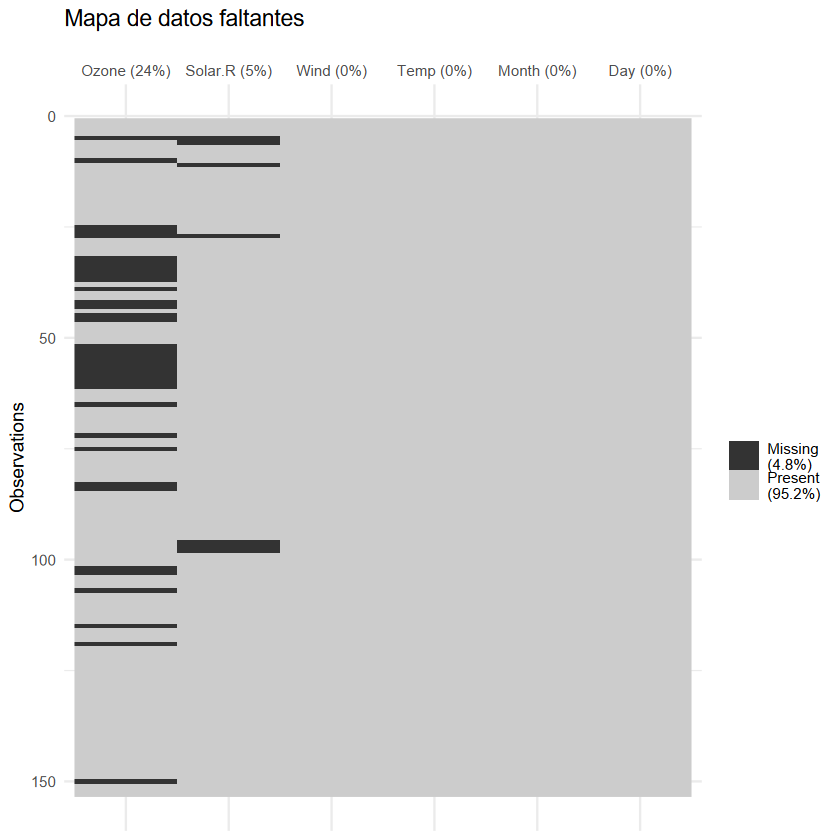

In [19]:
vis_miss(airquality) +
  labs(title = "Mapa de datos faltantes") +
  theme_minimal() 

Encontrar patrones de datos faltantes según una variable categórica.

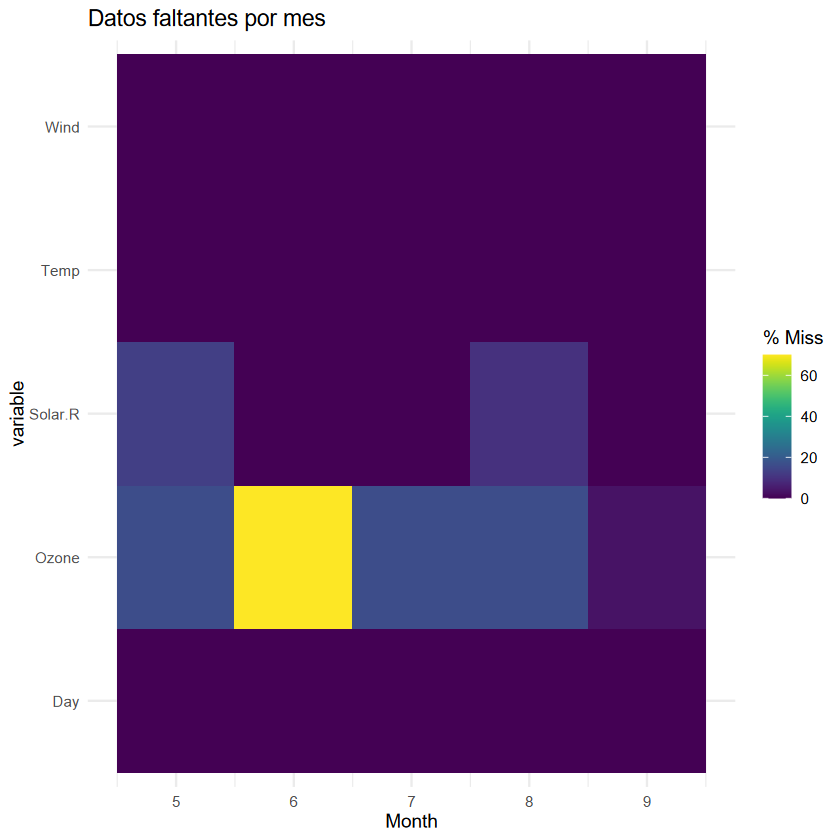

In [4]:

gg_miss_fct(x = airquality, fct = Month) +
  labs(title = "Datos faltantes por mes") +
  theme_minimal()



Pendiente libreria `VIM`

## Calidad de la información

## Preprocesamiento

## Análisis univariado y multivariado